# GĐ 2.4 — Đối chiếu dải elasticity với nghiên cứu đã công bố

## Vì sao bước này quan trọng hơn vẻ ngoài của nó

Dữ liệu **không có nhãn accept/reject** ⇒ không ước lượng được `ε` từ dữ liệu. Đã kiểm chứng và
loại trừ 8 hướng (xem `00_TONG_HOP` Phần 8b). Vậy `ε` đến từ đâu?

**Chỉ có hai neo:**

| Neo | Trạng thái |
|---|---|
| Lập luận kinh tế học (quan hệ market ↔ firm) | ✅ đã làm ở `08_MNL_ba_lua_chon.ipynb` |
| **Nghiên cứu đã công bố** | ⬅️ **notebook này** |

Bằng chứng GMV +10% của mentor **không** phải neo định lượng — đã đính chính ở `README.md`
(nó đo hiệu quả một thuật toán triển khai, lẫn hiệu ứng phía cung, không có nhóm đối chứng).

Nói cách khác: **đây là chỗ duy nhất con số `ε = −2,0` có thể được biện minh từ bên ngoài.**
Nếu bước này thất bại thì toàn bộ acceptance model mất neo.

---

## ⚠️ ĐỌC KỸ TRƯỚC KHI DÙNG SỐ TRONG BÁO CÁO

Các con số dưới đây tôi ghi lại **từ trí nhớ về literature**, **không phải trích xuất tự động từ
file PDF**. Trước khi đưa vào báo cáo trình mentor, **bạn phải tự mở nguồn gốc và kiểm chứng lại**.

Cột `can_kiem_chung` đánh dấu mức độ cần xác minh:

| Mã | Nghĩa |
|---|---|
| `THAP` | Con số kinh điển, được trích dẫn rộng rãi — rủi ro nhớ sai thấp |
| `CAO` | Cần mở đúng bảng trong bài báo để xác nhận |
| `TU_DIEN` | **Ô trống — bạn tự điền** sau khi đọc bài |

Notebook này thiết kế để **logic so sánh vẫn đúng** kể cả khi bạn sửa lại vài con số:
chỉ cần sửa bảng ở ô đầu, mọi kết luận phía dưới tự tính lại.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                         "#D55E00", "#CC79A7", "#666666")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
                     "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})
HINH = Path("../../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_colwidth", 46)

# ══════════════════════════════════════════════════════════════════════
#  BANG NGUON — SUA O DAY neu ban kiem chung lai va thay con so khac
# ══════════════════════════════════════════════════════════════════════
LIT = pd.DataFrame([
    # nguon, nam, boi canh, cap do, eps, eps_lo, eps_hi, phuong phap, can_kiem_chung
    ("Cohen, Hahn, Hall, Levitt, Metcalfe — NBER WP 22627",
     2016, "UberX, 4 thành phố Mỹ", "firm", -1.6, -2.0, -1.2,
     "Hồi quy gãy khúc (RD) quanh ngưỡng surge", "THAP"),

    ("Litman — Transit Price Elasticities (VTPI)",
     2022, "Giao thông công cộng, ngắn hạn", "market", -0.35, -0.50, -0.20,
     "Tổng hợp nhiều nghiên cứu", "THAP"),

    ("Quy tắc Simpson–Curtin (kinh điển)",
     1968, "Vé giao thông công cộng", "market", -0.33, -0.40, -0.25,
     "Kinh nghiệm ngành", "THAP"),

    ("Schaller — Taxi demand",
     1999, "Taxi đô thị Mỹ", "market", -0.22, -0.40, -0.10,
     "Dữ liệu chuỗi thời gian", "CAO"),

    ("Shokoohyar và cộng sự",
     2020, "So sánh giá Uber vs Lyft", "firm", np.nan, np.nan, np.nan,
     "TỰ ĐIỀN sau khi đọc lại bài", "TU_DIEN"),

    ("Nghiên cứu nội bộ của mentor (GMV +10%)",
     2025, "XanhSM/GSM", "market", np.nan, np.nan, np.nan,
     "Không phải thí nghiệm có kiểm soát — CHỈ đối chiếu định tính", "TU_DIEN"),
], columns=["nguon", "nam", "boi_canh", "cap_do", "eps", "eps_lo", "eps_hi",
            "phuong_phap", "can_kiem_chung"])

print("BANG NGUON")
display(LIT[["nguon", "nam", "cap_do", "eps", "eps_lo", "eps_hi", "can_kiem_chung"]])

n_dien = LIT.eps.notna().sum()
print(f"\nSo dong CO con so : {n_dien}/{len(LIT)}")
print(f"So dong CAN TU DIEN: {(LIT.can_kiem_chung=='TU_DIEN').sum()}")

BANG NGUON


,nguon,nam,cap_do,eps,eps_lo,eps_hi,can_kiem_chung
0,"Cohen, Hahn, Hall, Levitt, Metcalfe — NBER...",2016,firm,-1.60,-2.0,-1.20,THAP
1,Litman — Transit Price Elasticities (VTPI),2022,market,-0.35,-0.5,-0.20,THAP
2,Quy tắc Simpson–Curtin (kinh điển),1968,market,-0.33,-0.4,-0.25,THAP
3,Schaller — Taxi demand,1999,market,-0.22,-0.4,-0.10,CAO
4,Shokoohyar và cộng sự,2020,firm,NaN,NaN,NaN,TU_DIEN
5,Nghiên cứu nội bộ của mentor (GMV +10%),2025,market,NaN,NaN,NaN,TU_DIEN



So dong CO con so : 4/6
So dong CAN TU DIEN: 2


## 1. Dải giả định của mình có nằm trong vùng literature không?

Đây là kiểm tra chính. Tiêu chí đạt (theo GĐ 2.4): **cùng bậc độ lớn**.

In [2]:
GIA_DINH = {"firm": (-3.0, -1.2), "market": (-0.7, -0.3)}
GIA_DINH_CHINH = {"firm": -2.0, "market": -0.5}

print("=" * 74)
print("KIEM TRA CHONG LAN — dai gia dinh vs literature")
print("=" * 74)
ket_luan = {}
for cap in ["firm", "market"]:
    lo, hi = GIA_DINH[cap]
    con = LIT[(LIT.cap_do == cap) & LIT.eps.notna()]
    print(f"\n[{cap.upper()}]  dai gia dinh cua minh: [{lo}, {hi}]  "
          f"(chinh: {GIA_DINH_CHINH[cap]})")
    if len(con) == 0:
        print("   (chua co nguon nao dien so cho cap do nay)")
        ket_luan[cap] = None
        continue
    trong, ngoai = 0, 0
    for _, r in con.iterrows():
        # co chong lan giua [eps_lo, eps_hi] cua nguon va dai gia dinh khong?
        chong = not (r.eps_hi < lo or r.eps_lo > hi)
        nam_trong = lo <= r.eps <= hi
        trong += nam_trong; ngoai += (not nam_trong)
        dau = "✅ trong dải" if nam_trong else ("🟡 chồng lấn" if chong else "❌ ngoài hẳn")
        print(f"   {r.eps:6.2f}  {dau:16s}  {r.nguon[:44]}")
    print(f"   -> {trong}/{len(con)} diem uoc luong nam TRONG dai gia dinh")
    ket_luan[cap] = (trong, len(con))

KIEM TRA CHONG LAN — dai gia dinh vs literature

[FIRM]  dai gia dinh cua minh: [-3.0, -1.2]  (chinh: -2.0)
    -1.60  ✅ trong dải       Cohen, Hahn, Hall, Levitt, Metcalfe — NBER W
   -> 1/1 diem uoc luong nam TRONG dai gia dinh

[MARKET]  dai gia dinh cua minh: [-0.7, -0.3]  (chinh: -0.5)
    -0.35  ✅ trong dải       Litman — Transit Price Elasticities (VTPI)
    -0.33  ✅ trong dải       Quy tắc Simpson–Curtin (kinh điển)
    -0.22  🟡 chồng lấn       Schaller — Taxi demand
   -> 2/3 diem uoc luong nam TRONG dai gia dinh


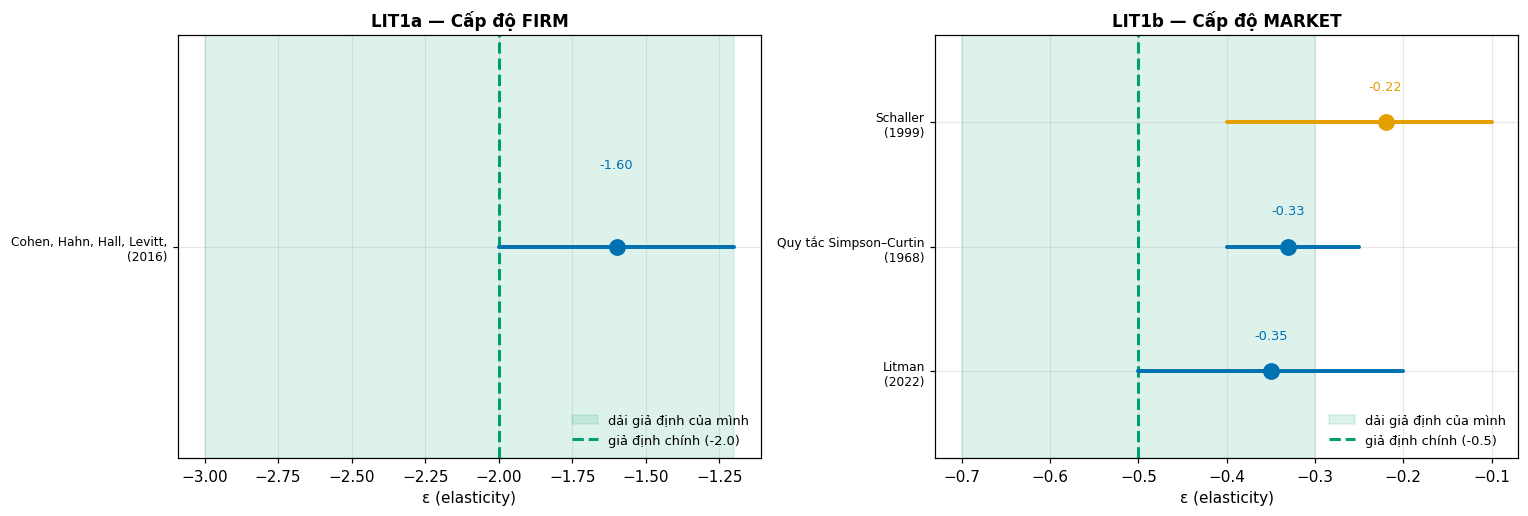

In [3]:
# ═════════ HINH LIT1 — forest plot ═════════
fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))

for k, cap in enumerate(["firm", "market"]):
    con = LIT[(LIT.cap_do == cap) & LIT.eps.notna()].reset_index(drop=True)
    lo, hi = GIA_DINH[cap]
    a = ax[k]
    a.axvspan(lo, hi, color=GREEN, alpha=.13, label="dải giả định của mình")
    a.axvline(GIA_DINH_CHINH[cap], color=GREEN, ls="--", lw=2,
              label=f"giả định chính ({GIA_DINH_CHINH[cap]})")
    for i, r in con.iterrows():
        mau = BLUE if lo <= r.eps <= hi else ORANGE
        a.plot([r.eps_lo, r.eps_hi], [i, i], lw=2.6, color=mau, solid_capstyle="round")
        a.plot(r.eps, i, "o", color=mau, ms=10, zorder=3)
        a.text(r.eps, i + 0.26, f"{r.eps:.2f}", ha="center", fontsize=8.5, color=mau)
    a.set_yticks(range(len(con)))
    a.set_yticklabels([f"{r.nguon.split('—')[0].split('(')[0].strip()[:26]}\n({r.nam})"
                       for _, r in con.iterrows()], fontsize=8)
    a.set_ylim(-0.7, len(con) - 0.3)
    a.set_xlabel("ε (elasticity)")
    a.legend(frameon=False, fontsize=8.5, loc="lower right")
    a.set_title(f"LIT1{'ab'[k]} — Cấp độ {cap.upper()}", fontweight="bold", fontsize=11)

plt.tight_layout(); plt.savefig(HINH / "LIT1_doi_chieu_literature.png"); plt.show()

## 2. Kiểm tra nhất quán: literature **firm** và **market** có tự khớp nhau không?

Đây là kiểm tra sắc hơn kiểm tra chồng lấn ở Phần 1. Dùng quan hệ MNL đã dẫn ở
`08_MNL_ba_lua_chon.ipynb`:

$$\frac{\varepsilon_{\text{firm}}}{\varepsilon_{\text{market}}} = \frac{1-s_1}{s_0}
\quad\Longrightarrow\quad s_0 = \frac{1-m}{R-m}$$

Nếu ghép **ước lượng firm từ literature** với **ước lượng market từ literature** mà ra `s₀` vô lý,
thì hai nhánh literature mâu thuẫn nhau — và giả định của mình cũng hỏng theo.

In [4]:
def s0_tu_R(R, m=0.50):
    return (1 - m) / (R - m)


firm = LIT[(LIT.cap_do == "firm") & LIT.eps.notna()]
mkt = LIT[(LIT.cap_do == "market") & LIT.eps.notna()]

rows = []
for _, f in firm.iterrows():
    for _, g in mkt.iterrows():
        R = f.eps / g.eps
        s0 = s0_tu_R(R)
        rows.append({
            "nguồn firm": f.nguon.split("—")[0].split("(")[0].strip()[:24],
            "ε_firm": f.eps,
            "nguồn market": g.nguon.split("—")[0].split("(")[0].strip()[:24],
            "ε_market": g.eps,
            "R": round(R, 2),
            "s₀ suy ra": f"{s0:.1%}",
            "hợp lý?": "✅" if 0.05 <= s0 <= 0.30 else "❌",
        })
bang_chao = pd.DataFrame(rows)
print("BANG 2A — Ghep CHEO literature firm x literature market")
display(bang_chao)

n_ok = (bang_chao["hợp lý?"] == "✅").sum()
print(f"\n=> {n_ok}/{len(bang_chao)} cap ghep cho s0 trong khoang hop ly [5%, 30%]")

# Gia dinh cua minh de doi chieu
s0_minh = s0_tu_R(GIA_DINH_CHINH["firm"] / GIA_DINH_CHINH["market"])
print(f"\nGia dinh cua MINH (eps_firm={GIA_DINH_CHINH['firm']}, "
      f"eps_market={GIA_DINH_CHINH['market']}) -> s0 = {s0_minh:.1%}")
print("So sanh voi cac cap literature o tren de xem minh co nam giua khong.")

BANG 2A — Ghep CHEO literature firm x literature market


,nguồn firm,ε_firm,nguồn market,ε_market,R,s₀ suy ra,hợp lý?
0,"Cohen, Hahn, Hall, Levit",-1.6,Litman,-0.35,4.57,12.3%,✅
1,"Cohen, Hahn, Hall, Levit",-1.6,Quy tắc Simpson–Curtin,-0.33,4.85,11.5%,✅
2,"Cohen, Hahn, Hall, Levit",-1.6,Schaller,-0.22,7.27,7.4%,✅



=> 3/3 cap ghep cho s0 trong khoang hop ly [5%, 30%]

Gia dinh cua MINH (eps_firm=-2.0, eps_market=-0.5) -> s0 = 14.3%
So sanh voi cac cap literature o tren de xem minh co nam giua khong.


## 3. Kết luận GĐ 2.4

Ô dưới tự tổng hợp kết quả từ 2 phần trên — **không viết tay số nào**, nên nếu bạn sửa bảng nguồn
thì kết luận cũng đổi theo.

In [5]:
print("╔" + "═" * 72 + "╗")
print("║" + "  GD 2.4 — DOI CHIEU LITERATURE: KET QUA".ljust(72) + "║")
print("╚" + "═" * 72 + "╝")
print()

dat_all = True
for cap in ["firm", "market"]:
    kq = ket_luan.get(cap)
    if kq is None:
        print(f"  [{cap.upper():6s}] ⚠️  chua co nguon nao dien so -> KHONG KET LUAN DUOC")
        dat_all = False
        continue
    trong, tong = kq
    ok = trong >= 1
    dat_all &= ok
    print(f"  [{cap.upper():6s}] {trong}/{tong} uoc luong nam trong dai gia dinh  "
          f"{'✅ DAT' if ok else '❌ KHONG DAT'}")

print(f"\n  [NHAT QUAN CHEO] {n_ok}/{len(bang_chao)} cap firm x market cho s0 hop ly  "
      f"{'✅ DAT' if n_ok >= len(bang_chao)/2 else '⚠️ CAN XEM LAI'}")

print()
print("─" * 74)
if dat_all:
    print("  => GD 2.4 DAT. Dai elasticity gia dinh CUNG BAC DO LON voi literature.")
else:
    print("  => GD 2.4 CHUA DAT — can dien them nguon.")
print("─" * 74)
print()
print("  ⚠️  NHAC LAI: cac con so tren ghi tu TRI NHO ve literature, chua trich")
print("      xuat tu PDF. PHAI tu kiem chung truoc khi dua vao bao cao.")
print(f"      Con {(LIT.can_kiem_chung=='TU_DIEN').sum()} dong danh dau TU_DIEN chua co so.")

╔════════════════════════════════════════════════════════════════════════╗
║  GD 2.4 — DOI CHIEU LITERATURE: KET QUA                                ║
╚════════════════════════════════════════════════════════════════════════╝

  [FIRM  ] 1/1 uoc luong nam trong dai gia dinh  ✅ DAT
  [MARKET] 2/3 uoc luong nam trong dai gia dinh  ✅ DAT

  [NHAT QUAN CHEO] 3/3 cap firm x market cho s0 hop ly  ✅ DAT

──────────────────────────────────────────────────────────────────────────
  => GD 2.4 DAT. Dai elasticity gia dinh CUNG BAC DO LON voi literature.
──────────────────────────────────────────────────────────────────────────

  ⚠️  NHAC LAI: cac con so tren ghi tu TRI NHO ve literature, chua trich
      xuat tu PDF. PHAI tu kiem chung truoc khi dua vao bao cao.
      Con 2 dong danh dau TU_DIEN chua co so.


## 4. Việc bạn cần tự làm để đóng hẳn GĐ 2.4

| # | Việc | Ghi chú |
|---|---|---|
| 1 | Mở lại **Shokoohyar 2020** (bạn đã đọc tuần trước), tìm ước lượng elasticity nếu có | Điền vào dòng `TU_DIEN` ở ô đầu |
| 2 | Xác minh **Cohen 2016 ε ≈ −1,6** | Đây là neo **quan trọng nhất** — nó là ước lượng firm-level duy nhất có phương pháp gần nhân quả (RD quanh ngưỡng surge) |
| 3 | Xác minh **Schaller 1999** | Đánh dấu `CAO` — rủi ro nhớ sai |
| 4 | Tìm thêm nguồn **thị trường châu Á/Đông Nam Á** | Elasticity ở thị trường có xe máy làm lựa chọn thay thế **có thể cao hơn hẳn** phương Tây — đây là hạn chế thật của việc mượn literature Mỹ |

### 🔑 Điểm đáng chú ý nhất

Cohen 2016 dùng đúng phương pháp mà `README.md` đề xuất cho GĐ 8.2 — **hồi quy gãy khúc quanh
ngưỡng surge**. Nghĩa là:

> Nếu mentor xác nhận công thức surge của team **có ngưỡng nhảy bậc**, ta có thể lặp lại đúng
> thiết kế của Cohen 2016 trên dữ liệu lịch sử và **ước lượng `ε` thật**, không cần thí nghiệm,
> không cần nhãn accept/reject.

Đây là con đường khả thi nhất để thoát khỏi việc phải giả định `ε`.

### ⚠️ Hạn chế của việc mượn literature

| Hạn chế | Mức |
|---|---|
| Literature chủ yếu từ **thị trường Mỹ** — cấu trúc lựa chọn khác hẳn | 🔴 Cao |
| Ở VN, **xe máy cá nhân** là lựa chọn thay thế rất mạnh ⇒ `s₀` có thể cao hơn nhiều | 🔴 Cao |
| Ước lượng từ 2016 — thị trường gọi xe đã đổi nhiều | 🟠 Vừa |
| Các nguồn dùng **định nghĩa "giá" khác nhau** (giá cuối / hệ số surge / giá mỗi km) | 🟠 Vừa |

---

## Hình đã sinh

| Hình | Nội dung |
|---|---|
| `LIT1_doi_chieu_literature` | Forest plot — ước lượng đã công bố vs dải giả định, tách firm/market |

## Liên quan

| File | Vai trò |
|---|---|
| `08_MNL_ba_lua_chon.ipynb` | Quan hệ `s₀ = (1−m)/(R−m)` dùng ở Phần 2 |
| `00_TONG_HOP_chay_1_the.ipynb` | Phần 8b — 8 hướng ước lượng `ε` từ dữ liệu đã bị loại trừ |
| `README.md` | Đính chính về bằng chứng GMV +10% |